In [1]:
from xrd_processing import read_data, combine_data, plot_data, smooth_data
from pybaselines import Baseline

left_data = read_data(r'zgm\20240106_GeSbSn_100nm_300C_1h\22-analyze\22-000-0000_exported.xy')
right_data = read_data(r'zgm\20240106_GeSbSn_100nm_300C_1h\46-analyze\46-000-0000_exported.xy')

data = combine_data(left_data, right_data)

raw_data = data.copy()

# Polynomial Baselines

In [2]:
poly_order = 20
baseline_fitter = Baseline(x_data=data['two_theta'])
baseline = {}


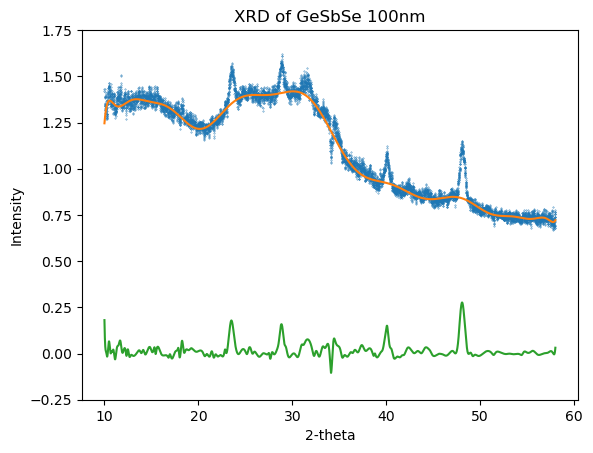

In [3]:
data = raw_data.copy()
baseline['imodpoly'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['imodpoly']['intensity'], baseline['imodpoly']['params'] = baseline_fitter.imodpoly(raw_data['intensity'], poly_order=poly_order)
data['intensity'] = data['intensity'] - baseline['imodpoly']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['imodpoly'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

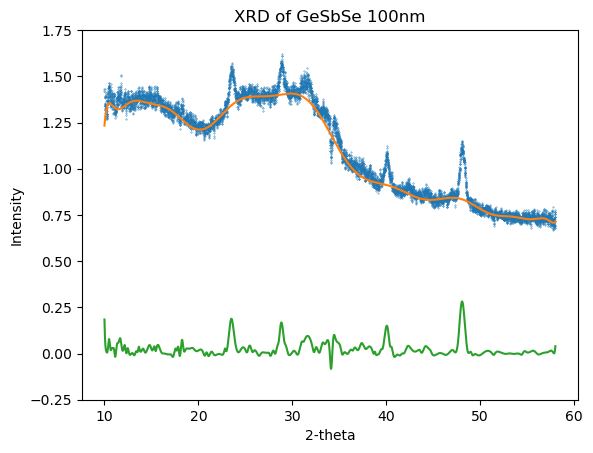

In [3]:

data = raw_data.copy()
baseline['penalized_poly'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['penalized_poly']['intensity'], baseline['penalized_poly']['params'] = baseline_fitter.penalized_poly(raw_data['intensity'], poly_order=poly_order)
data['intensity'] = data['intensity'] - baseline['penalized_poly']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['penalized_poly'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')


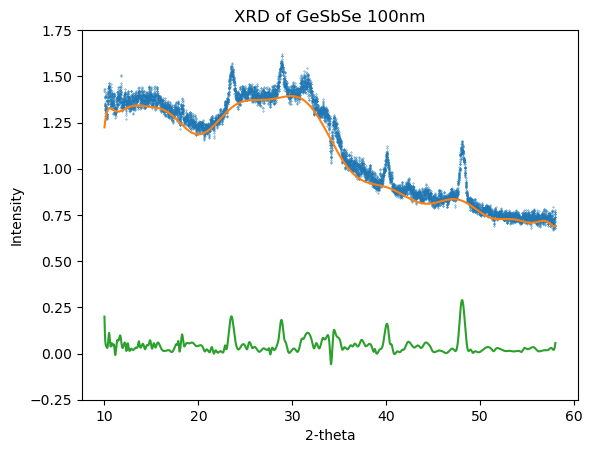

In [5]:

data = raw_data.copy()
baseline['goldindec'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['goldindec']['intensity'], baseline['goldindec']['params'] = baseline_fitter.goldindec(raw_data['intensity'], poly_order=poly_order)
data['intensity'] = data['intensity'] - baseline['goldindec']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['goldindec'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')


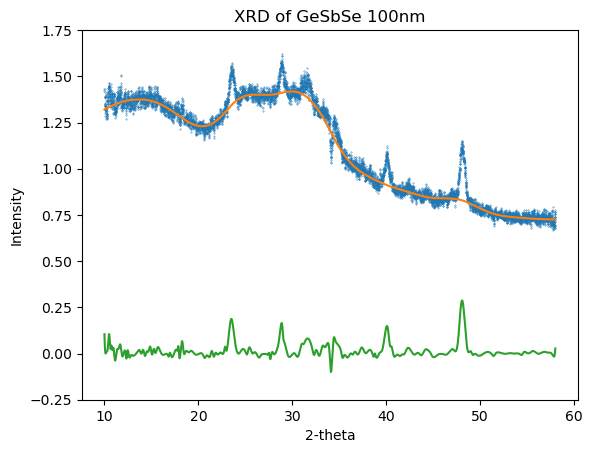

In [4]:
data = raw_data.copy()
baseline['loess'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['loess']['intensity'], baseline['loess']['params'] = baseline_fitter.loess(raw_data['intensity'], poly_order=2)
data['intensity'] = data['intensity'] - baseline['loess']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['loess'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')


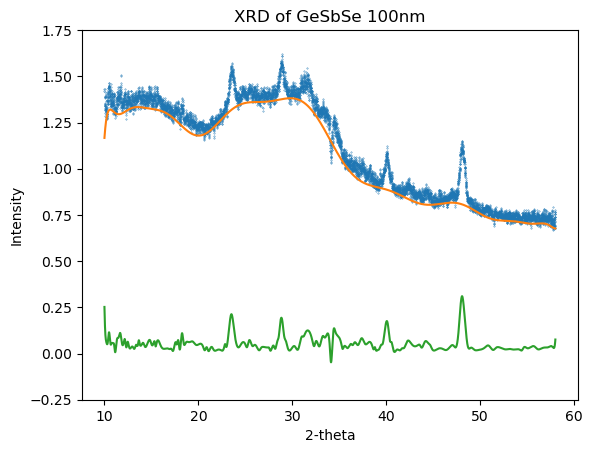

In [7]:
data = raw_data.copy()
baseline['quant_reg'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['quant_reg']['intensity'], baseline['quant_reg']['params'] = baseline_fitter.quant_reg(raw_data['intensity'], poly_order=poly_order)
data['intensity'] = data['intensity'] - baseline['quant_reg']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['quant_reg'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')


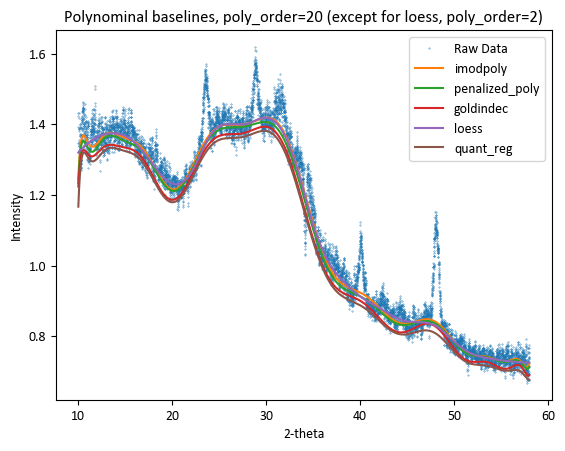

In [8]:
# Plot all data in baseline together in one figure, with one raw data and all the baseline data. Finally, save the figure in high resolution.
import matplotlib.pyplot as plt

# Change font into Calibri
plt.rcParams['font.family'] = 'Calibri'

# Plot raw data
plt.plot(raw_data['two_theta'], raw_data['intensity'], 'o', markersize=0.3, label='Raw Data')

# Plot baseline data
for key, value in baseline.items():
    plt.plot(value['two_theta'], value['intensity'], label=key)

# Set plot title and labels
plt.title(f'Polynominal baselines, poly_order={poly_order} (except for loess, poly_order=2)')
plt.xlabel('2-theta')
plt.ylabel('Intensity')

# Add legend
plt.legend()

# Save the figure in high resolution
plt.savefig(f'baseline_comparison/polynominal_{poly_order}.png', dpi=600)

# Show the plot
plt.show()


# Whittaker Baselines

In [9]:
baseline_fitter = Baseline(x_data=data['two_theta'])
baseline = {}


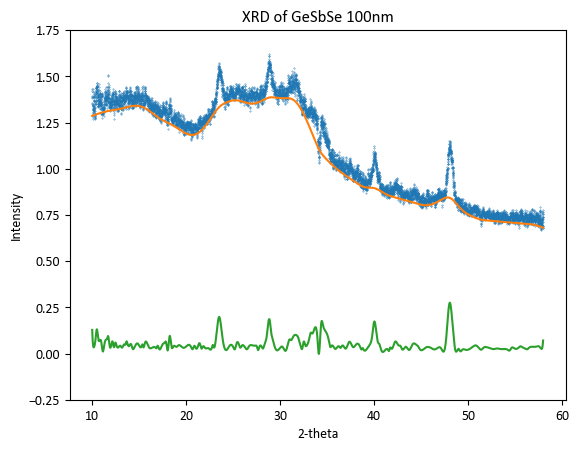

In [10]:
data = raw_data.copy()
baseline['asls'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['asls']['intensity'], baseline['asls']['params'] = baseline_fitter.asls(raw_data['intensity'], lam=1e7)
data['intensity'] = data['intensity'] - baseline['asls']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['asls'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

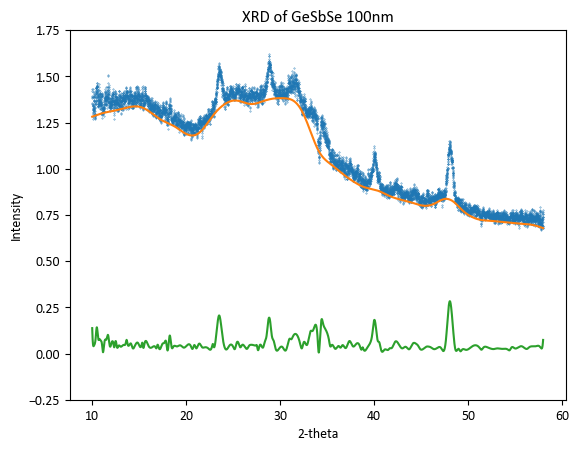

In [11]:
data = raw_data.copy()
baseline['airpls'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['airpls']['intensity'], baseline['airpls']['params'] = baseline_fitter.airpls(raw_data['intensity'], lam=1e7)
data['intensity'] = data['intensity'] - baseline['airpls']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['airpls'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

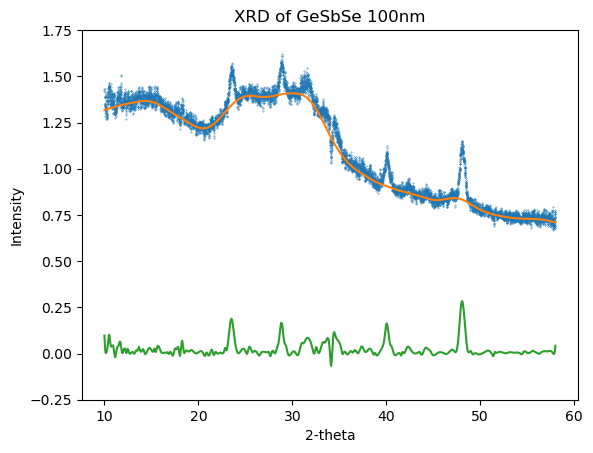

In [5]:
data = raw_data.copy()
baseline['psalsa'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['psalsa']['intensity'], baseline['psalsa']['params'] = baseline_fitter.psalsa(raw_data['intensity'], lam=1e8)
data['intensity'] = data['intensity'] - baseline['psalsa']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['psalsa'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

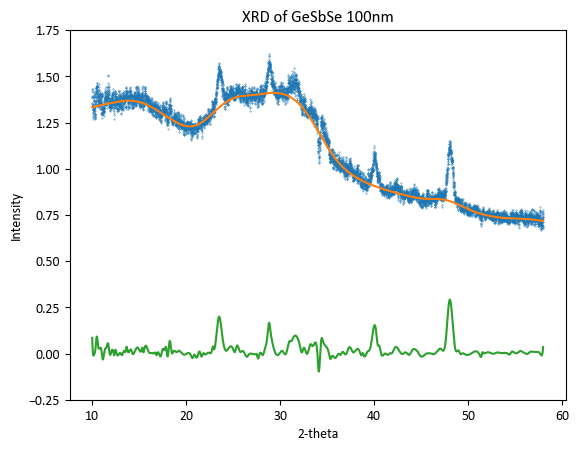

In [13]:
data = raw_data.copy()
baseline['aspls'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['aspls']['intensity'], baseline['aspls']['params'] = baseline_fitter.aspls(raw_data['intensity'], lam=1e10)
data['intensity'] = data['intensity'] - baseline['aspls']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['aspls'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

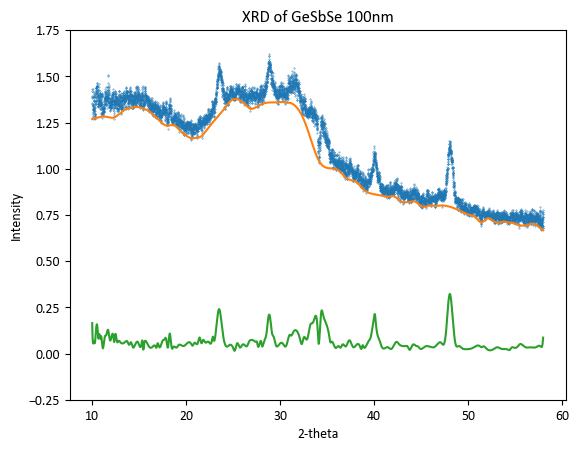

In [14]:
data = raw_data.copy()
baseline['derpsalsa'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['derpsalsa']['intensity'], baseline['derpsalsa']['params'] = baseline_fitter.derpsalsa(raw_data['intensity'], lam=1e5)
data['intensity'] = data['intensity'] - baseline['derpsalsa']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['derpsalsa'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

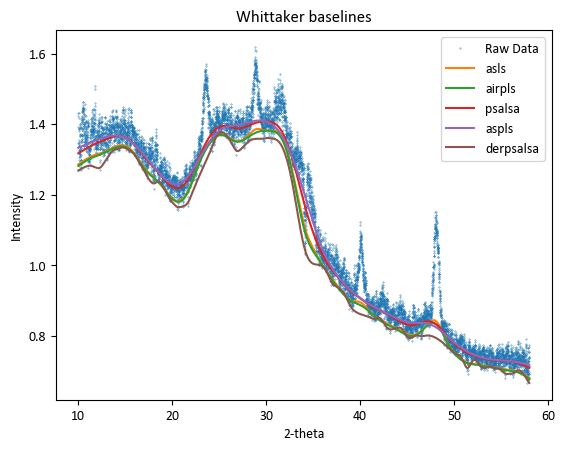

In [15]:
# Plot all data in baseline together in one figure, with one raw data and all the baseline data. Finally, save the figure in high resolution.
import matplotlib.pyplot as plt

# Change font into Calibri
plt.rcParams['font.family'] = 'Calibri'

# Plot raw data
plt.plot(raw_data['two_theta'], raw_data['intensity'], 'o', markersize=0.3, label='Raw Data')

# Plot baseline data
for key, value in baseline.items():
    plt.plot(value['two_theta'], value['intensity'], label=key)

# Set plot title and labels
plt.title(f'Whittaker baselines')
plt.xlabel('2-theta')
plt.ylabel('Intensity')

# Add legend
plt.legend()

# Save the figure in high resolution
plt.savefig(f'baseline_comparison/whittaker.png', dpi=600)

# Show the plot
plt.show()


# Morphological Baselines

In [16]:
baseline_fitter = Baseline(x_data=data['two_theta'])
baseline = {}

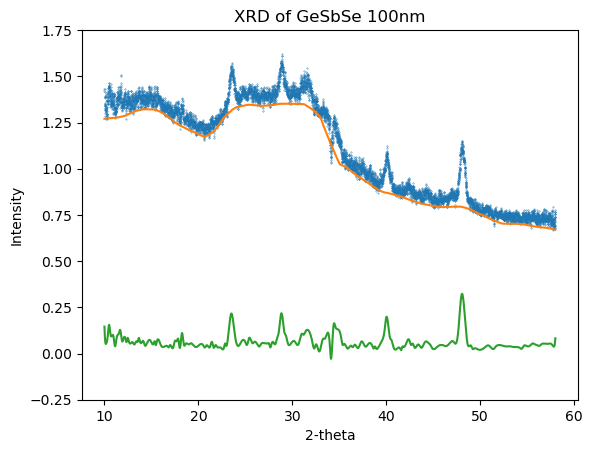

In [6]:
data = raw_data.copy()
baseline['rolling_ball'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['rolling_ball']['intensity'], baseline['rolling_ball']['params'] = baseline_fitter.rolling_ball(raw_data['intensity'], half_window=200)
data['intensity'] = data['intensity'] - baseline['rolling_ball']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['rolling_ball'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

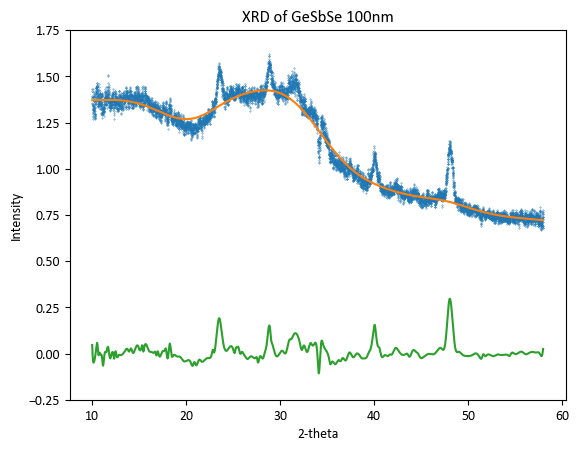

In [18]:
data = raw_data.copy()
baseline['mpspline'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['mpspline']['intensity'], baseline['mpspline']['params'] = baseline_fitter.mpspline(raw_data['intensity'], half_window=10)
data['intensity'] = data['intensity'] - baseline['mpspline']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['mpspline'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')


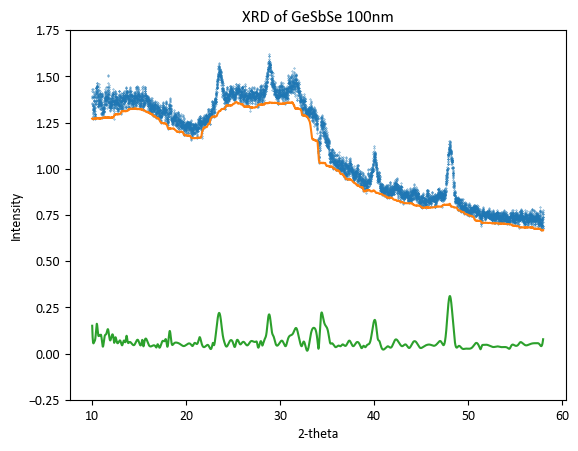

In [19]:
data = raw_data.copy()
baseline['jbcd'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['jbcd']['intensity'], baseline['jbcd']['params'] = baseline_fitter.jbcd(raw_data['intensity'], half_window=150)
data['intensity'] = data['intensity'] - baseline['jbcd']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['jbcd'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

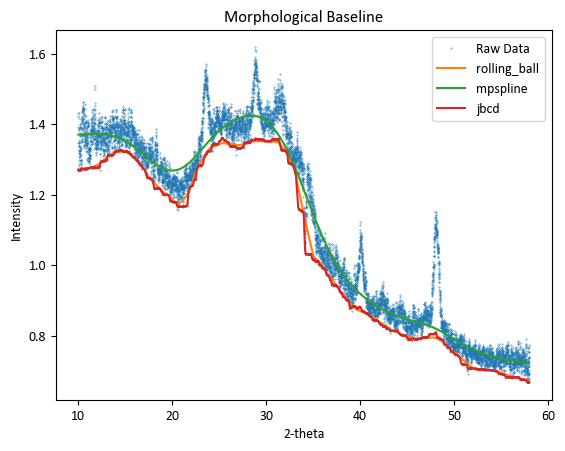

In [20]:
# Plot all data in baseline together in one figure, with one raw data and all the baseline data. Finally, save the figure in high resolution.
import matplotlib.pyplot as plt

# Change font into Calibri
plt.rcParams['font.family'] = 'Calibri'

# Plot raw data
plt.plot(raw_data['two_theta'], raw_data['intensity'], 'o', markersize=0.3, label='Raw Data')

# Plot baseline data
for key, value in baseline.items():
    plt.plot(value['two_theta'], value['intensity'], label=key)

# Set plot title and labels
plt.title(f'Morphological Baseline')
plt.xlabel('2-theta')
plt.ylabel('Intensity')

# Add legend
plt.legend()

# Save the figure in high resolution
plt.savefig(f'baseline_comparison/morphological.png', dpi=600)

# Show the plot
plt.show()

# Spline Baselines

In [21]:
baseline_fitter = Baseline(x_data=data['two_theta'])
baseline = {}
lam = 1e3

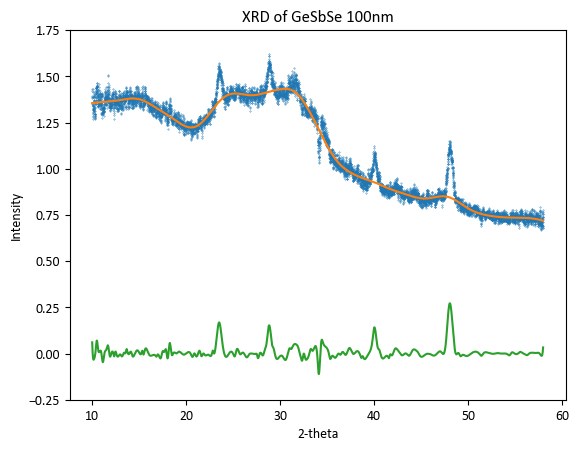

In [22]:
data = raw_data.copy()
baseline['mixture_model'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['mixture_model']['intensity'], baseline['mixture_model']['params'] = baseline_fitter.mixture_model(raw_data['intensity'], lam=lam)
data['intensity'] = data['intensity'] - baseline['mixture_model']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['mixture_model'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

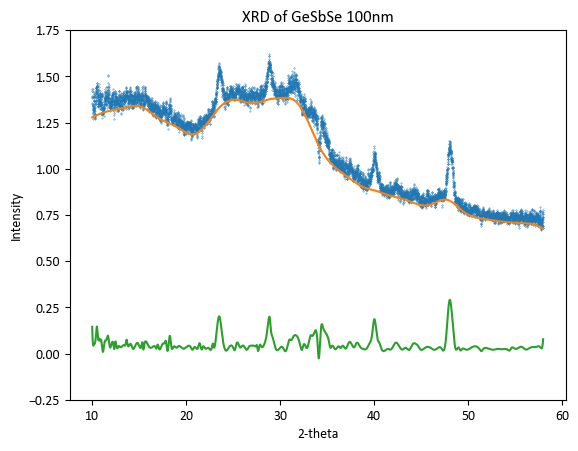

In [23]:
data = raw_data.copy()
baseline['irsqr'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['irsqr']['intensity'], baseline['irsqr']['params'] = baseline_fitter.irsqr(raw_data['intensity'], lam=lam)
data['intensity'] = data['intensity'] - baseline['irsqr']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['irsqr'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

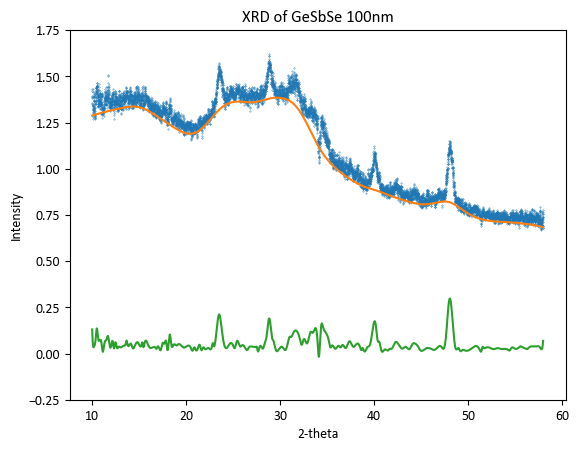

In [24]:
data = raw_data.copy()
baseline['pspline_asls'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['pspline_asls']['intensity'], baseline['pspline_asls']['params'] = baseline_fitter.pspline_asls(raw_data['intensity'], lam=50)
data['intensity'] = data['intensity'] - baseline['pspline_asls']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['pspline_asls'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

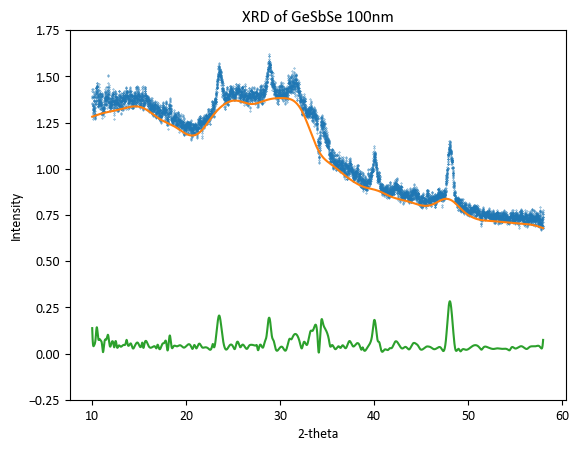

In [25]:
data = raw_data.copy()
baseline['pspline_airpls'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['pspline_airpls']['intensity'], baseline['pspline_airpls']['params'] = baseline_fitter.pspline_airpls(raw_data['intensity'], lam=10)
data['intensity'] = data['intensity'] - baseline['pspline_airpls']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['pspline_airpls'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')


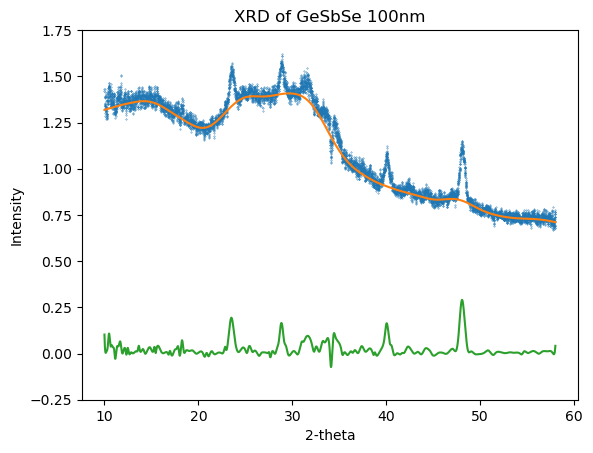

In [7]:
data = raw_data.copy()
baseline['pspline_psalsa'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['pspline_psalsa']['intensity'], baseline['pspline_psalsa']['params'] = baseline_fitter.pspline_psalsa(raw_data['intensity'], lam=200)
data['intensity'] = data['intensity'] - baseline['pspline_psalsa']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['pspline_psalsa'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

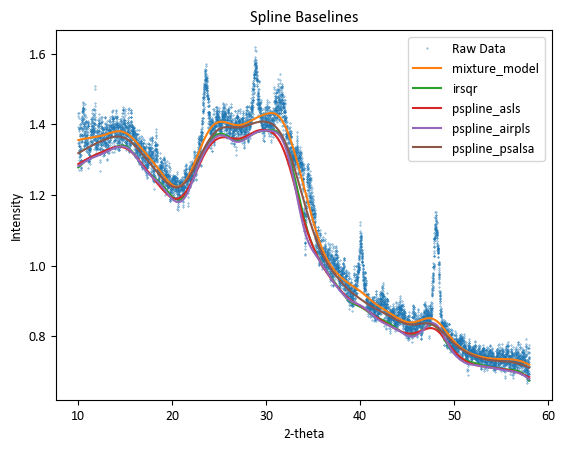

In [27]:
# Plot all data in baseline together in one figure, with one raw data and all the baseline data. Finally, save the figure in high resolution.
import matplotlib.pyplot as plt

# Change font into Calibri
plt.rcParams['font.family'] = 'Calibri'

# Plot raw data
plt.plot(raw_data['two_theta'], raw_data['intensity'], 'o', markersize=0.3, label='Raw Data')

# Plot baseline data
for key, value in baseline.items():
    plt.plot(value['two_theta'], value['intensity'], label=key)

# Set plot title and labels
plt.title(f'Spline Baselines')
plt.xlabel('2-theta')
plt.ylabel('Intensity')

# Add legend
plt.legend()

# Save the figure in high resolution
plt.savefig(f'baseline_comparison/spline.png', dpi=600)

# Show the plot
plt.show()

# Smoothing Baselines

In [28]:
baseline_fitter = Baseline(x_data=data['two_theta'])
baseline = {}

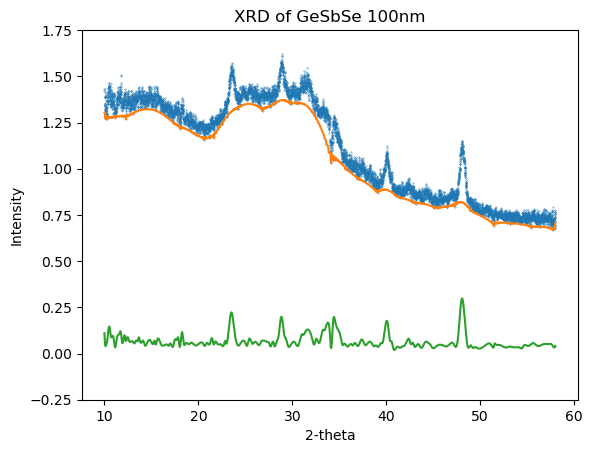

In [8]:
data = raw_data.copy()
baseline['snip'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['snip']['intensity'], baseline['snip']['params'] = baseline_fitter.snip(raw_data['intensity'], max_half_window=50)
data['intensity'] = data['intensity'] - baseline['snip']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['snip'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

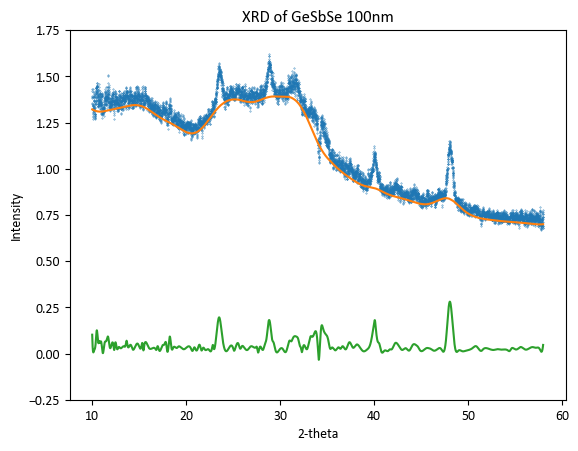

In [49]:
data = raw_data.copy()
baseline['ipsa'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['ipsa']['intensity'], baseline['ipsa']['params'] = baseline_fitter.ipsa(raw_data['intensity'], half_window=300)
data['intensity'] = data['intensity'] - baseline['ipsa']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['ipsa'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

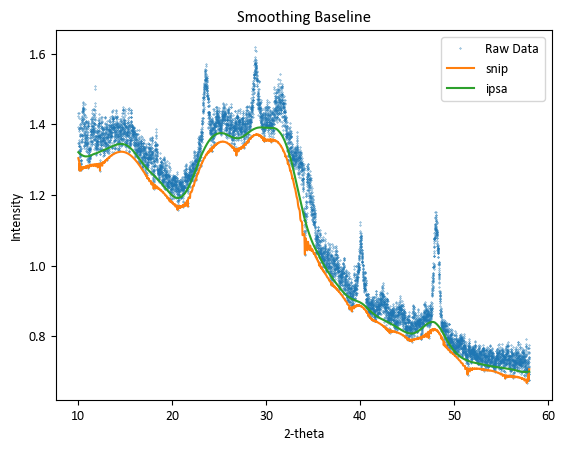

In [31]:
# Plot all data in baseline together in one figure, with one raw data and all the baseline data. Finally, save the figure in high resolution.
import matplotlib.pyplot as plt

# Change font into Calibri
plt.rcParams['font.family'] = 'Calibri'

# Plot raw data
plt.plot(raw_data['two_theta'], raw_data['intensity'], 'o', markersize=0.3, label='Raw Data')

# Plot baseline data
for key, value in baseline.items():
    plt.plot(value['two_theta'], value['intensity'], label=key)

# Set plot title and labels
plt.title(f'Smoothing Baseline')
plt.xlabel('2-theta')
plt.ylabel('Intensity')

# Add legend
plt.legend()

# Save the figure in high resolution
plt.savefig(f'baseline_comparison/smoothing.png', dpi=600)

# Show the plot
plt.show()

# Classification Baselines

In [32]:
baseline_fitter = Baseline(x_data=data['two_theta'])
baseline = {}

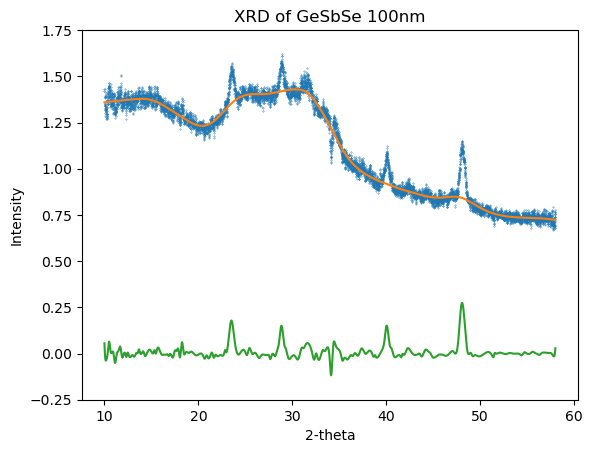

In [9]:
data = raw_data.copy()
baseline['fabc'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['fabc']['intensity'], baseline['fabc']['params'] = baseline_fitter.fabc(raw_data['intensity'], lam=1e9)
data['intensity'] = data['intensity'] - baseline['fabc']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['fabc'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

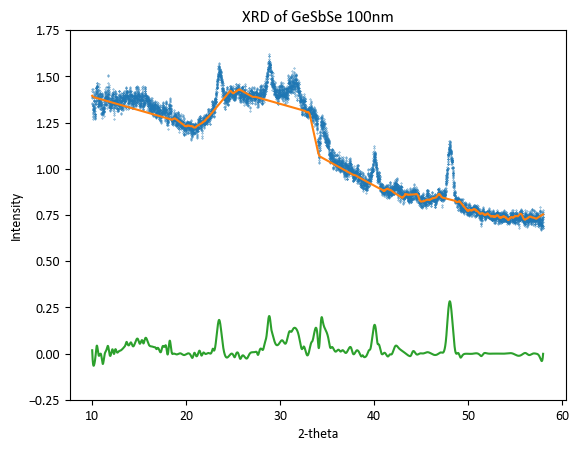

In [34]:
data = raw_data.copy()
baseline['fastchrom'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['fastchrom']['intensity'], baseline['fastchrom']['params'] = baseline_fitter.fastchrom(raw_data['intensity'], half_window=30)
data['intensity'] = data['intensity'] - baseline['fastchrom']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['fastchrom'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

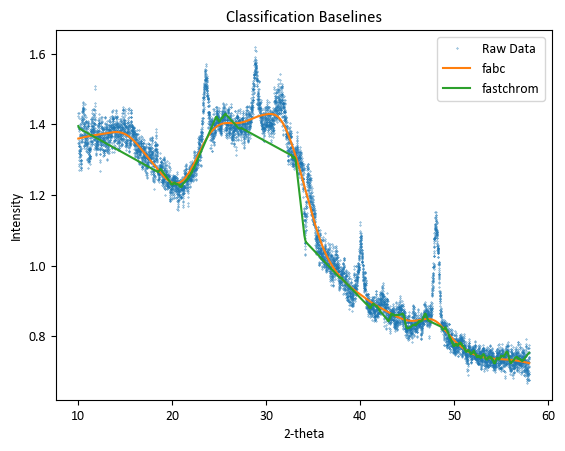

In [35]:
# Plot all data in baseline together in one figure, with one raw data and all the baseline data. Finally, save the figure in high resolution.
import matplotlib.pyplot as plt

# Change font into Calibri
plt.rcParams['font.family'] = 'Calibri'

# Plot raw data
plt.plot(raw_data['two_theta'], raw_data['intensity'], 'o', markersize=0.3, label='Raw Data')

# Plot baseline data
for key, value in baseline.items():
    plt.plot(value['two_theta'], value['intensity'], label=key)

# Set plot title and labels
plt.title(f'Classification Baselines')
plt.xlabel('2-theta')
plt.ylabel('Intensity')

# Add legend
plt.legend()

# Save the figure in high resolution
plt.savefig(f'baseline_comparison/classification.png', dpi=600)

# Show the plot
plt.show()

# Others

In [36]:
baseline_fitter = Baseline(x_data=data['two_theta'])
baseline = {}

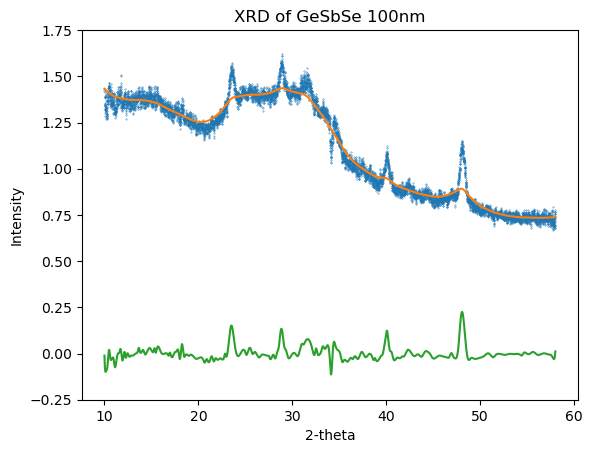

In [10]:
data = raw_data.copy()
baseline['beads'] = {
    "two_theta" : data['two_theta'],
    "intensity" : [],
    "params": None
    }
baseline['beads']['intensity'], baseline['beads']['params'] = baseline_fitter.beads(raw_data['intensity'], 0.0007)
data['intensity'] = data['intensity'] - baseline['beads']['intensity']
smoothed_data = smooth_data(data, 51)
plot_data(data=raw_data, baseline_data=baseline['beads'], smoothed_data=smoothed_data, fitted_data=None, title='XRD of GeSbSe 100nm', x_label='2-theta', y_label='Intensity')

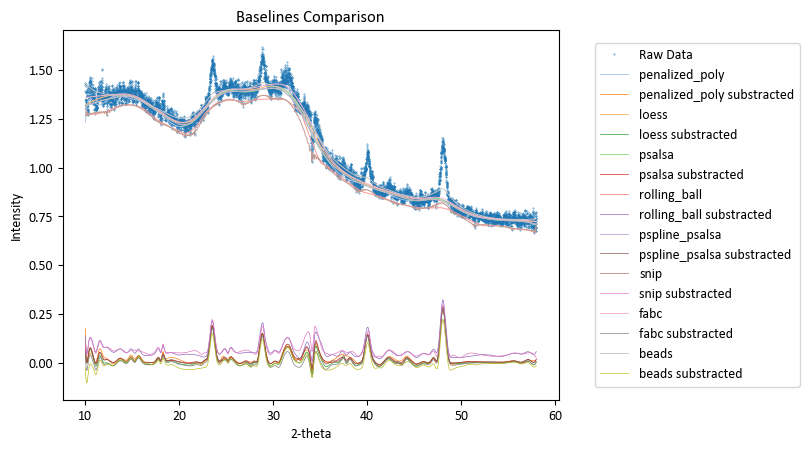

In [14]:
# Plot all data in baseline together in one figure, with one raw data and all the baseline data. Finally, save the figure in high resolution.
import matplotlib.pyplot as plt
import matplotlib

# Change font into Calibri
plt.rcParams['font.family'] = 'Calibri'

cmap = 'tab20'
# Plot raw data
plt.plot(raw_data['two_theta'], raw_data['intensity'], 'o', markersize=0.3, label='Raw Data', color=matplotlib.colormaps[cmap](0))

# Plot baseline data
for i, (key, value) in enumerate(baseline.items()):
    plt.plot(value['two_theta'], value['intensity'], label=key, linewidth=0.7, color=matplotlib.colormaps[cmap](int(2*i+1)))
    data = raw_data.copy()
    data['intensity'] = raw_data['intensity'] - value['intensity']
    smoothed_data = smooth_data(data, 101)
    plt.plot(smoothed_data['two_theta'], smoothed_data['intensity'], label=f'{key} substracted', linewidth=0.5, color=matplotlib.colormaps[cmap](int(2*i+2)))

# Set plot title and labels
plt.title(f'Baselines Comparison')
plt.xlabel('2-theta')
plt.ylabel('Intensity')

# Add legend
plt.legend(loc='right',bbox_to_anchor=(1.5,0.5))

# Save the figure in high resolution
plt.savefig(f'baseline_comparison/all.png', dpi=600, bbox_inches='tight')

plt.show()